In [7]:
%load_ext autoreload
%autoreload 2
import unittest 
import sys
import os

sys.path.append(os.getcwd() + '/..')

from backend.AppApi import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import numpy as np
import pandas as pd
from Constants import Const
import matplotlib.pyplot as plt

In [9]:
old_dose_df = pd.read_csv('old_dose_20260421.csv')
new_dose_df = pd.read_csv('new_dose_20260421.csv')

id_col = 'id'

old_ids = set(old_dose_df[id_col])
new_ids = set(new_dose_df[id_col])
ids_in_both = old_ids & new_ids
n_ids_in_both = len(ids_in_both)

print(f'Unique ids in old_dose_df: {len(old_ids)}')
print(f'Unique ids in new_dose_df: {len(new_ids)}')
print(f'Ids present in both files: {n_ids_in_both}')

# Prefer old_dose_df when the same id appears in both; append ids only in new_dose_df.
merged_dose_df = pd.concat([old_dose_df, new_dose_df], ignore_index=True)
merged_dose_df = merged_dose_df.drop_duplicates(subset=id_col, keep='first')

print(f'merged_dose_df rows: {len(merged_dose_df)}')

Unique ids in old_dose_df: 432
Unique ids in new_dose_df: 270
Ids present in both files: 80
merged_dose_df rows: 622


In [ ]:
old_dose_df = pd.read_csv('dw_df_stiefel_id_20260421.csv')
old_dose_df2 = pd.read_csv('old_dose_20260421.csv')
new_dose_df = pd.read_csv('new_dose_20260421.csv')

id_col = 'id'

old_ids = set(old_dose_df[id_col])
old_ids2 = set(old_dose_df2[id_col])
new_ids = set(new_dose_df[id_col])
all_unique_ids = old_ids | old_ids2 | new_ids

print(f'Unique ids in old_dose_df: {len(old_ids)}')
print(f'Unique ids in old_dose_df2: {len(old_ids2)}')
print(f'Unique ids in new_dose_df: {len(new_ids)}')
print(f'Unique ids across all 3 files (union): {len(all_unique_ids)}')

# Keep the first occurrence by concatenation order: old_dose_df -> old_dose_df2 -> new_dose_df.
merged_dose_df = pd.concat([old_dose_df, old_dose_df2, new_dose_df], ignore_index=True)
merged_dose_df = merged_dose_df.drop_duplicates(subset=id_col, keep='first')

print(f'merged_dose_df rows: {len(merged_dose_df)}')

Unique ids in old_dose_df: 349
Unique ids in old_dose_df2: 337
Unique ids in new_dose_df: 225
Unique ids across all 3 files (union): 561
merged_dose_df rows: 561


In [31]:
from ast import literal_eval

original = pd.read_csv('../data/minimal_dose_cluster_dataset.csv')


def _as_sequence(x):
    """Match load_dose_symptom_data: CSV cells may be repr-of-list strings."""
    if isinstance(x, str):
        return literal_eval(x)
    return x


def symptom_length_report(df, name='df'):
    """Why add_symptom_groups fails: np.stack needs identical shape for every row."""
    s_cols = [c for c in df.columns if 'symptoms_' in c and 'original' not in c]
    print(f"[{name}] rows={len(df)}  symptom columns={len(s_cols)}")
    if not s_cols:
        print("(no symptom columns)")
        return []

    bad = []
    for c in s_cols:
        lengths = df[c].map(lambda x: len(_as_sequence(x)))
        uniq = lengths.unique()
        uniq_sorted = sorted(uniq)
        if len(uniq_sorted) != 1:
            vc = lengths.value_counts().sort_index()
            worst = vc.head(10)
            bad.append((c, uniq_sorted, worst))
            print(f"\n>>> [{name}] LENGTH MISMATCH — {c}")
            print(f"    unique lengths: {uniq_sorted}")
            print(f"    counts (sorted by length):\n{worst}")

    if not bad:
        lens_ref = df[s_cols[0]].map(lambda x: len(_as_sequence(x)))
        L = int(lens_ref.iloc[0])
        print(f"\n[{name}] Each symptom column has a single length across all rows; ref {s_cols[0]} length = {L}.")
    else:
        print(f"\n[{name}] {len(bad)} column(s) with varying lengths → add_symptom_groups ValueError.")

    if s_cols and 'dates' in df.columns:
        d_lens = df['dates'].map(lambda x: len(_as_sequence(x)))
        for c in s_cols[:3]:
            s_lens = df[c].map(lambda x: len(_as_sequence(x)))
            mism_dt = (s_lens != d_lens).sum()
            if mism_dt:
                print(f"\n[{name}] Row count where len({c}) != len(dates): {mism_dt}")
        L0 = df[s_cols[0]].map(lambda x: len(_as_sequence(x)))
        any_sym_mismatch = False
        for c in s_cols[1:]:
            mism_cols = (df[c].map(lambda x: len(_as_sequence(x))) != L0).sum()
            if mism_cols:
                any_sym_mismatch = True
                print(f"[{name}] len({s_cols[0]}) != len({c}) on {mism_cols} rows")
        if not bad and not any_sym_mismatch:
            print(f"\n[{name}] dates and all symptom columns align with each other.")

    return bad


symptom_length_report(original, name='minimal (reference)')
# Same check on merged export — uncomment after saving CSV next to notebook:
symptom_length_report(pd.read_csv('merged_dose_20260421.csv'), name='merged')

[minimal (reference)] rows=349  symptom columns=28

[minimal (reference)] Each symptom column has a single length across all rows; ref symptoms_activity length = 13.

[minimal (reference)] dates and all symptom columns align with each other.
[merged] rows=501  symptom columns=28

[merged] Each symptom column has a single length across all rows; ref symptoms_activity length = 13.

[merged] dates and all symptom columns align with each other.


[]

In [12]:
#this loads in the processed dataset, does some cleaning, adds in some dose thresholds, and parses the string lists into actual lists
# data = load_dose_symptom_data('minimal_dose_cluster_dataset.csv')
# data.head()
merged_dose_df.to_csv('merged_dose_20260421.csv')
data = load_dose_symptom_data(use_lstm=False, file='./merged_dose_20260421.csv')

In [14]:
data.drop(columns=['Unnamed: 0'],inplace=True)
# data.drop(columns=['Unnamed: 0.1'],inplace=True)
data

,id,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,...,total_mean_dose,Parotid_Gland_limit,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Larynx_limit,Esophagus_limit
0,8,"[14279.47998046875, 12866.363525390625, 7139.7...","[35.72055395268319, 23.816881203970524, 36.247...","[297.0, 1768.0, 341.0, 1308.0, 4070.0, 2579.0,...","[5827.0, 3008.0, 6272.0, 6034.0, 5747.0, 6842....","[96.375, 100.0, 95.6875, 100.0, 100.0, 100.0, ...","[91.5625, 100.0, 80.0, 100.0, 100.0, 100.0, 10...","[88.25, 100.0, 75.5, 99.0, 100.0, 100.0, 100.0...","[85.6875, 93.875, 72.5625, 98.375, 100.0, 100....","[82.9375, 31.1875, 70.3125, 96.25, 100.0, 100....",...,1733.224947,True,False,False,True,True,True,True,False,True
1,23,"[6974.945068359375, 16417.694091796875, 6562.9...","[30.499019492025983, 22.78990464240902, 32.607...","[184.0, 1369.0, 98.0, 1356.0, 3583.0, 2759.0, ...","[5088.0, 3084.0, 6896.0, 5966.0, 6443.0, 6304....","[84.875, 100.0, 64.875, 100.0, 100.0, 100.0, 1...","[78.375, 100.0, 61.71875, 100.0, 100.0, 100.0,...","[75.375, 97.625, 59.5625, 98.9375, 100.0, 100....","[72.5625, 81.875, 58.75, 96.3125, 100.0, 100.0...","[72.4375, 25.546875, 57.875, 92.9375, 100.0, 1...",...,1827.967819,True,False,False,True,False,True,True,False,True
2,24,"[14724.42626953125, 14765.625, 6632.9956054687...","[22.765716284275324, 33.629034598214275, 56.96...","[1.0, 2114.0, 4179.0, 3625.0, 3459.0, 2969.0, ...","[4362.0, 3864.0, 6126.0, 7216.0, 5552.0, 5877....","[80.0625, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[70.3125, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[64.75, 100.0, 100.0, 100.0, 100.0, 100.0, 100...","[61.5, 100.0, 100.0, 100.0, 100.0, 100.0, 100....","[58.03125, 98.5, 100.0, 100.0, 100.0, 100.0, 1...",...,1795.847534,True,True,False,True,False,True,False,False,False
3,26,"[10428.309631347656, 17159.777069091797, 4182....","[19.083991985203443, 21.81411015361559, 48.068...","[352.0, 572.0, 909.0, 3685.0, 599.0, 609.0, 38...","[3401.0, 3709.0, 5978.0, 7046.0, 3621.0, 4159....","[95.4375, 100.0, 100.0, 100.0, 100.0, 100.0, 1...","[61.53125, 78.6875, 99.9375, 100.0, 48.46875, ...","[55.34375, 75.625, 99.75, 100.0, 24.296875, 33...","[49.1875, 70.625, 99.0625, 100.0, 18.40625, 22...","[44.75, 47.5, 98.75, 100.0, 5.3359375, 16.25, ...",...,1790.729475,True,True,False,True,True,True,True,True,False
4,28,"[10272.979736328125, 21972.10121154785, 10272....","[33.69805989786887, 20.803234820775426, 33.698...","[1075.0, 754.0, 1075.0, 1075.0, 532.0, 484.0, ...","[5966.0, 3283.0, 5966.0, 5966.0, 3305.0, 5288....","[100.0, 100.0, 100.0, 100.0, 100.0, 98.5, 100....","[100.0, 95.0, 100.0, 100.0, 33.375, 42.9375, 6...","[96.5, 79.875, 96.5, 96.5, 15.3671875, 34.4062...","[86.1875, 62.75, 86.1875, 86.1875, 8.390625, 2...","[73.4375, 27.28125, 73.4375, 73.4375, 3.335937...",...,1208.798443,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617,2087,"[24.6375, 25.9369, 7.7186, 11.1037, 3.3446, 7....","[10.4994, 13.4459, 53.3147, 44.0878, 30.4089, ...","[0.0, 0.0, 15.9, 13.3, 26.9, 20.1, 24.7, 55.7,...","[29.7, 22.1, 65.5, 65.7, 39.9, 43.5, 67.5, 70....","[58.4375, 76.5625, 100.0, 100.0, 100.0, 100.0,...","[48.0, 70.4375, 100.0, 100.0, 100.0, 100.0, 10...","[30.3125, 61.0625, 100.0, 99.3125, 100.0, 100....","[20.265625, 5.2578125, 99.5625, 95.875, 100.0,...","[7.0078125, 0.0, 99.0625, 92.5, 100.0, 84.9375...",...,1506.170500,True,False,False,True,True,True,False,True,False
618,2095,"[11.9981, 23.1559, 10.9215, 10.0237, 3.8475, 7...","[29.0344, 11.6382, 45.4762, 46.3755, 35.6528, ...","[6.5, 0.0, 11.3, 11.1, 30.9, 22.5, 28.1, 49.1,...","[51.1, 26.3, 65.7, 58.9, 51.5, 55.7, 56.7, 70....","[100.0, 65.8125, 100.0, 100.0, 100.0, 100.0, 1...","[92.625, 60.53125, 100.0, 100.0, 100.0, 100.0,...","[83.9375, 43.46875, 97.875, 99.75, 100.0, 100....","[79.625, 21.625, 93.0, 98.9375, 100.0, 100.0, ...","[75.9375, 0.5830078125, 88.3125, 95.9375, 100....",...,1766.636

In [15]:
#see AppApi.add_confunder_dose_limits for the <Organ>_limit at the end
#based on rules in literature cited in the paper
for col in data.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,data[col].iloc[0])
    print()

id 8

volume [14279.47998046875, 12866.363525390625, 7139.739990234375, 5500.030517578125, 2698.516845703125, 8964.84375, 2900.390625, 1384.27734375, 22704.620361328125, 24879.913330078125, 12310.1806640625, 70371.55151367188, 745.697021484375, 29630.126953125, 10386.199951171875, 7918.39599609375, 27228.240966796875, 74087.67700195312, 1557.31201171875, 27953.338623046875, 11193.695068359375, 12322.540283203125, 9570.465087890625, 26725.616455078125, 22119.598388671875, 15111.6943359375, 10398.5595703125, 2101.13525390625, 11955.87158203125, 24595.64208984375, 52066.95556640625, 5697.784423828125, 5747.222900390625, 14876.861572265625, 177826.08032226562, 103272.85766601562, 5170.440673828125, 5088.043212890625, 5944.976806640625, 1058.807373046875]

mean_dose [35.72055395268319, 23.816881203970524, 36.24780727062894, 42.946247191011246, 49.90435114503816, 48.690312499999976, 41.851960227272706, 66.4098214285714, 6.866349119941932, 38.615870531401, 45.916221552878135, 58.2397342075990

In [16]:
Const.organ_list

['Esophagus',
 'Spinal_Cord',
 'Lt_Brachial_Plexus',
 'Rt_Brachial_Plexus',
 'Cricopharyngeal_Muscle',
 'Cricoid_cartilage',
 'IPC',
 'MPC',
 'Brainstem',
 'Larynx',
 'Thyroid_cartilage',
 'Rt_Sternocleidomastoid_M',
 'Rt_Mastoid',
 'Rt_Parotid_Gland',
 'Rt_Medial_Pterygoid_M',
 'Rt_Lateral_Pterygoid_M',
 'Rt_Masseter_M',
 'Lt_Sternocleidomastoid_M',
 'Lt_Mastoid',
 'Lt_Parotid_Gland',
 'Lt_Submandibular_Gland',
 'Lt_Medial_Pterygoid_M',
 'Lt_Lateral_Pterygoid_M',
 'Lt_Masseter_M',
 'Supraglottic_Larynx',
 'SPC',
 'Rt_Submandibular_Gland',
 'Hyoid_bone',
 'Soft_Palate',
 'Genioglossus_M',
 'Tongue',
 'Rt_Ant_Digastric_M',
 'Lt_Ant_Digastric_M',
 'Mylogeniohyoid_M',
 'Extended_Oral_Cavity',
 'Mandible',
 'Hard_Palate',
 'Lower_Lip',
 'Upper_Lip',
 'Glottic_Area']

In [17]:
#clustering works conceptuallby be selecting a set of dose/organ features and a set of organs,
#and converting that into a 1d vector for each patient ,which is input into cluster
def to_value_array(df,features,organ_subset):
    organ_positions = [Const.organ_list.index(o) for o in organ_subset]
    vals = np.stack(df[features].apply(lambda x: np.stack([np.array([ii[i] for i in organ_positions]).astype(float) for ii in x]).ravel(),axis=1).values)
    return vals

to_value_array(data,features=['V15','V25'],organ_subset=['IPC','MPC','SPC'])

array([[100.    , 100.    , 100.    , 100.    , 100.    , 100.    ],
       [100.    , 100.    , 100.    , 100.    , 100.    , 100.    ],
       [100.    , 100.    , 100.    , 100.    , 100.    , 100.    ],
       ...,
       [100.    , 100.    , 100.    ,  66.375 ,  98.9375, 100.    ],
       [100.    , 100.    , 100.    , 100.    , 100.    , 100.    ],
       [100.    , 100.    , 100.    ,  95.875 , 100.    , 100.    ]])

In [48]:
#clustering is done in the add_sd_dose_clusters in appAPi
#this does the function of to_value_array and then runs clustering on the data
#by default, we use a gaussian mixture model
#this returns a dataframe with a 'dose_clusters' column with the cluster labels
# clusters = add_sd_dose_clusters(data,
#                      features=['V15','V25'], #dose features e.g. VX, DX, mean_dose, volume
#                      organ_subset=['IPC','MPC','SPC'], #organs to use in clustering
#                      n_clusters=7, #number of clusters
#                      normalize=True #whether to normalize the input data
#                     )
# clusters[['id','dose_clusters']].iloc[0:10]

clusters = add_sd_dose_clusters(data,
                     features=None, #dose features e.g. VX, DX, mean_dose, volume
                     organ_subset=None, #organs to use in clustering
                     n_clusters=4, #number of clusters
                     normalize=True #whether to normalize the input data
                    )
clusters[['id','dose_clusters']].iloc[0:10]

c:\Users\szhao69\AppData\Local\miniconda3\envs\HNC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\szhao69\AppData\Local\miniconda3\envs\HNC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\szhao69\AppData\Local\miniconda3\envs\HNC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\szhao69\AppData\Local\miniconda3\envs\HNC\Lib\sit

,id,dose_clusters
0,8,2
1,23,2
2,24,2
3,26,2
4,28,0
5,34,3
6,36,2
7,37,0
8,38,2
9,42,2


In [49]:
output_df = clusters[['id', 'dose_clusters']].copy()

output_df['id'] = 'STIEFEL_' + output_df['id'].astype(str)

output_df.to_csv('dose_clusters_20260421.csv', index=False)

In [ ]:
#clusters are ordered by mean_dose in reorder_clusters column (change the "by" argument to reorder clusters to change)
#this orders by the average number of people with t3 or t4
reorder_clusters(clusters,'dose_clusters',by='t_severe')[['id','dose_clusters']].iloc[0:10]

In [20]:
#We can also add in custom clustering and reducers
#reducers are e.g. dimensionality reduction done before the clustering
#reduers may also work with an autoencoder if you add a wrapper function to work with reducer.fit_transform(numpy_array)
from sklearn.decomposition import PCA

#see keyword_clusterer to see predefned cluster options
add_sd_dose_clusters(data,
                     clusterer=keyword_clusterer('kmeans',6),
                     reducer=PCA(3),
                     features=['V15','V25'], #dose features e.g. VX, DX, mean_dose, volume
                     organ_subset=['IPC','MPC','SPC'], #organs to use in clustering
                     normalize=True #whether to normalize the input data
                    )[['id','dose_clusters']].iloc[0:10]

c:\Users\szhao69\AppData\Local\miniconda3\envs\HNC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,id,dose_clusters
0,8,5
1,23,5
2,24,5
3,26,5
4,28,2
5,34,5
6,36,5
7,37,1
8,38,4
9,42,2


In [21]:
#we can preform likelihood ratio tests with the clusters and confounders for different binary symptom outcomes.
#this returns the dataframe with columns with results in the form 'cluster_<symptom>_<threshold>_<timepoint>' for each option tested
lrt_results = get_cluster_lrt(clusters,
                              symptoms=['drymouth'], #symptoms to test
                              confounders=['t4','n3'], #confounders to use in the lrt test
                              nWeekList=[[13,33]], #list of sets of week. we take the max over each list, so this is max drymouth between 6 weeks and 6 months post treatment
                              thresholds=[5]) #severity thresholds totest
lrt_results[['dose_clusters']+[c for c in lrt_results if 'cluster_drymouth_5_33wks' in c]].groupby('dose_clusters').first()

c:\Users\szhao69\Documents\GitHub\QubbedDataAnalysis\python/..\backend\AppApi.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.41863641920571126' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[in_clust].index,[colname+'_'+name]] = res[name]
c:\Users\szhao69\Documents\GitHub\QubbedDataAnalysis\python/..\backend\AppApi.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8080615023575332' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[in_clust].index,[colname+'_'+name]] = res[name]
c:\Users\szhao69\Documents\GitHub\QubbedDataAnalysis\python/..\backend\AppApi.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.41905517805364156'

""
dose_clusters
0
1
2
3


In [ ]:
#This section deals with rule explainers

In [22]:
#this processes the data into inputs in terms of dose featuers and outcomes
temp_x, temp_y = get_rule_inference_data(clusters,
                                         ['IPC','SPC'], #organs for inputs to consider
                                         ['drymouth'], #outcomes to consider
                                         ['V25','V30','mean_dose'],
                                         [13,33],
                                         include_limits=True)
temp_x.head()

,V25_IPC,V25_SPC,V30_IPC,V30_SPC,mean_dose_IPC,mean_dose_SPC,Parotid_Gland_limit,IPC_limit,IPC_limit2,MPC_limit,MPC_limit2,SPC_limit,SPC_limit2,Larynx_limit,Esophagus_limit
0,100.000000,100.0,99.125000,100.00000,41.851960,68.475769,1,0,0,1,1,1,1,0,1
1,100.000000,100.0,100.000000,100.00000,43.879899,66.566609,1,0,0,1,0,1,1,0,1
2,100.000000,100.0,100.000000,100.00000,50.744640,59.884944,1,1,0,1,0,1,0,0,0
3,100.000000,100.0,100.000000,100.00000,52.224735,67.431397,1,1,0,1,1,1,1,1,0
4,21.078125,72.0,16.765625,61.28125,17.433103,43.319443,1,0,0,0,0,0,0,0,0


In [23]:
temp_y.head()

,drymouth
0,8.0
1,8.0
2,8.0
3,5.0
4,3.0


In [24]:
#this generates a set of rules. second input is assumed to be a binary dataframe, but can technically have any integer input
#here we're generating rules to predict if a patient has drymouth (this is an option in the interface)
temprules = get_rule_df(temp_x,pd.DataFrame(temp_y > 5))
for k,v in temprules[0].items():
    print(k,v)
    print()

features ['V25_IPC']

thresholds [46.0]

splits [0       True
1       True
2       True
3       True
4      False
       ...  
617     True
618     True
619     True
620     True
621     True
Name: V25_IPC, Length: 622, dtype: bool]

rule 0       True
1       True
2       True
3       True
4      False
       ...  
617     True
618     True
619     True
620     True
621     True
Name: V25_IPC, Length: 622, dtype: bool

info 0.011112379235343667

odds_ratio 1.4946172248803828

lower_count 204

lower_tp 64

lower_mean 0.3137254901960784

upper_count 418

upper_tp 196

upper_mean 0.4688995215311005



In [25]:
#for generating rule explanations we actually use cluster membership 
#this tests all splits and save the memories and stuff lol
cluster_outcome = clusters.dose_clusters.apply(lambda x: x == clusters.dose_clusters.max())
cluster_rules = get_rule_df(temp_x,pd.DataFrame(cluster_outcome))
[[k['features'],k['thresholds'],k['info']] for k in cluster_rules[0:4]]

[[['V25_IPC'], [8.0], 0.011439367125294114],
 [['V25_IPC'], [10.0], 0.012405164757529452],
 [['V25_IPC'], [12.0], 0.013772961601439426],
 [['V25_IPC'], [14.0], 0.015159506402435685]]

In [30]:
#This is a version of the AppApi call that gets the rules to return to the interface, in case you want to generate those,
#The difference here is that in the AppAPI the cluster labels and arguments are passed as a json file in the request

#this returns of list of dictionaries with information about the rules
def get_rules(df,
                   organs=Const.organ_list[:],#organs to check
                   symptoms=['drymouth'],#symptom to check. I forget why it's a list and not just one
                   organ_features=['V5','V10','V15','V20','V25','V30','V35','V40','V45','V50','V55','V60','V65','V70','V75','V80','mean_dose','max_dose'],
                   s_dates=[33],
                   threshold=5, #threshold for the rule. e.g. we want to predict symptoms[0] > threshold
                   maxdepth=3,#max number of thresholds
                   min_odds=0,#used to trim the forward search
                   min_info=.08,#used to trim the forward search
                   criteria='info',#criteria used to chose rules, info or odds_ratio. odds_ratio is only positive
                   max_rules=3,#max number of rule sets to return
                   max_frontier=10,#used to trim forward search. 
                   granularity=1,#how granular to go in the splits (e.g. every 1 rad, every .1 rads
                   predict_cluster = -1,#if 1 or true, predict the cluster membership. otherwise we use the symptoms
                   cluster=None,
                   use_limits=False#wether to use dose limits in addition to the other stuff idk
             ):
    df.post_cluster = df.dose_clusters
    df = df.set_index('id')
    if predict_cluster is not None and predict_cluster >= 0:
        cluster = None
    dose_df, outcome_df = get_rule_inference_data(
            df,
            organs,
            symptoms,
            organ_features,
            s_dates,
            cluster=cluster,
            include_limits=use_limits,
        )
    symptom_bool = (outcome_df>=threshold)
    if predict_cluster is not None and predict_cluster >= 0:
        df['temp_outcome'] = df.post_cluster.apply(lambda x: x == predict_cluster)
        y = df[['temp_outcome']]
    else:
        y = symptom_bool
    rules = get_rule_df(dose_df,y,min_odds=min_odds,granularity=granularity)
    sort_rules = lambda rlist: sorted(rlist, key=lambda x: -x[criteria])
    rules = sort_rules(rules)
    min_info = min(rules[0].get('info',0.0)*.6,float(min_info))
    rules = [r for r in rules if r.get('info',0) >= min_info]
    if len(rules) > 800:
        rules = rules[:800]
    print('n rules',len(rules))
    frontier = [None]
    best_rules = []
    depth = 0
    while (depth < maxdepth) and (frontier is not None) and (len(frontier) > 0):
        frontier = get_best_rules(frontier,rules,y,min_odds=min_odds,criteria=criteria)
        frontier = sorted(frontier, key = lambda x: -x[criteria] if x is not None else 0)
        frontier = frontier[:max_frontier]
        depth += 1
        best_rules.extend(frontier)
        print('lb',len(best_rules))
        print()
    
    best_rules = sort_rules(best_rules)
    best_rules = best_rules[:max_rules]
    best_rules = joblib.Parallel(n_jobs=-2)(joblib.delayed(format_rule_json)((br,y,symptom_bool)) for br in best_rules)
    print([(r['features'],r.get('info')) for r in best_rules])
    pos_ids = y[y.values.astype(bool)].index.values.tolist()    
    for br in best_rules:
        br['target_ids'] = pos_ids
    return best_rules
    
test_rules = get_rules(clusters)
print(len(test_rules),'rules generated')
best_rule = test_rules[0]
print('best rule for predicting drymouth > 5 of the selected organs')
print('with a mutual information score with target outcome of ',best_rule['info'])
for organ,threshold in zip(best_rule['features'],best_rule['thresholds']):
    print(organ + ' > ' + str(threshold))


n rules 800
lb 10

lb 20

lb 30

[(['V10_Rt_Sternocleidomastoid_M', 'V25_MPC', 'V15_Rt_Brachial_Plexus'], 0.033634157835972), (['mean_dose_Rt_Sternocleidomastoid_M', 'V25_MPC', 'V15_Rt_Brachial_Plexus'], 0.033634157835972), (['V10_Hyoid_bone', 'V20_Rt_Brachial_Plexus', 'mean_dose_Rt_Sternocleidomastoid_M'], 0.03317769892108008)]
3 rules generated
best rule for predicting drymouth > 5 of the selected organs
with a mutual information score with target outcome of  0.033634157835972
V10_Rt_Sternocleidomastoid_M > 63.0
V25_MPC > 57.0
V15_Rt_Brachial_Plexus > 34.0


In [38]:
with open("20260421_rules.json", "w") as f:
    json.dump(test_rules, f, indent=4, default=lambda x: int(x) if isinstance(x, np.integer) else float(x) if isinstance(x, np.floating) else str(x))

In [39]:
#full breakdown of returned items
#upper and lower ids are the patient ids of the people above and below the threshold
#target ids is the list of people with a 1 in the thing we're predicting
for k,v in test_rules[0].items():
    print(k)
    print(v)
    print()

features
['V10_Rt_Sternocleidomastoid_M', 'V25_MPC', 'V15_Rt_Brachial_Plexus']

thresholds
[63.0, 57.0, 34.0]

info
0.033634157835972

odds_ratio
2.594230769230769

lower_count
142

lower_tp
26

lower_mean
0.18309859154929578

upper_count
480

upper_tp
228

upper_mean
0.475

upper_ids
[8, 23, 24, 26, 28, 34, 36, 38, 42, 45, 47, 51, 53, 54, 55, 58, 60, 66, 71, 80, 81, 82, 83, 85, 87, 88, 89, 90, 91, 93, 94, 95, 96, 98, 99, 101, 103, 105, 106, 108, 109, 110, 112, 116, 117, 118, 120, 121, 122, 126, 127, 128, 1477, 132, 137, 141, 1480, 145, 147, 148, 149, 153, 156, 157, 158, 159, 160, 161, 164, 165, 167, 1485, 170, 171, 173, 175, 176, 177, 180, 183, 1486, 186, 192, 193, 194, 201, 202, 205, 207, 208, 212, 213, 217, 219, 225, 227, 234, 235, 238, 243, 244, 245, 247, 248, 253, 255, 264, 265, 266, 272, 283, 292, 298, 300, 301, 305, 307, 309, 314, 319, 326, 331, 338, 340, 343, 347, 350, 355, 356, 358, 360, 364, 367, 368, 373, 378, 380, 381, 384, 385, 387, 389, 391, 392, 394, 403, 404, 405, 1507,

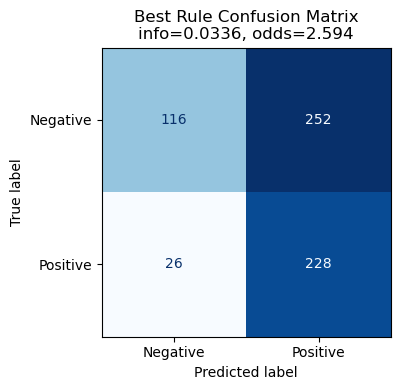

In [45]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Load rules exported from the notebook
with open("20260421_rules.json", "r") as f:
    rules = json.load(f)

def confusion_from_rule(rule):
    """
    Reconstruct confusion matrix from rule summary fields.
    Returns np.array([[TN, FP], [FN, TP]]).
    """
    upper_tp = int(rule["upper_tp"])
    upper_count = int(rule["upper_count"])
    lower_tp = int(rule["lower_tp"])
    lower_count = int(rule["lower_count"])
    odds_ratio = float(rule.get("odds_ratio", 1.0))

    # Match AppApi.format_rule_json behavior:
    # if odds_ratio < 1, prediction is inverted
    if odds_ratio >= 1:
        tp = upper_tp
        fp = upper_count - upper_tp
        fn = lower_tp
        tn = lower_count - lower_tp
    else:
        tp = lower_tp
        fp = lower_count - lower_tp
        fn = upper_tp
        tn = upper_count - upper_tp

    return np.array([[tn, fp], [fn, tp]], dtype=int)

# -------- Plot best rule (rules[0]) --------
best_rule = rules[0]
cm_best = confusion_from_rule(best_rule)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["Negative", "Positive"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(
    f"Best Rule Confusion Matrix\n"
    f"info={best_rule.get('info', float('nan')):.4f}, "
    f"odds={best_rule.get('odds_ratio', float('nan')):.3f}"
)
plt.tight_layout()
plt.show()

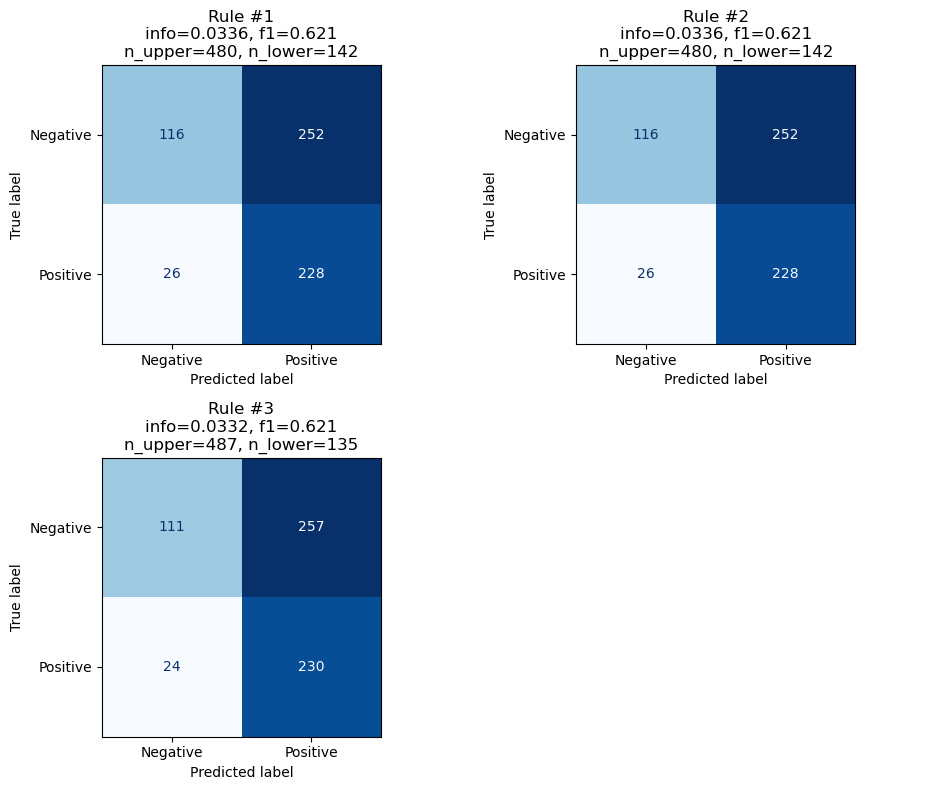

In [43]:
# -------- Optional: plot top-k rules --------
k = 4
k = min(k, len(rules))

ncols = 2
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i in range(k):
    r = rules[i]
    cm = confusion_from_rule(r)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(ax=axes[i], cmap="Blues", values_format="d", colorbar=False)
    axes[i].set_title(
        f"Rule #{i+1}\n"
        f"info={r.get('info', float('nan')):.4f}, "
        f"f1={r.get('f1', float('nan')):.3f}\n"
        f"n_upper={r['upper_count']}, n_lower={r['lower_count']}"
    )

for j in range(k, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()